# BinWaves example in Cantabria (Validation)

**In this notebook**: 
<br><br>
Here waves are reconstructed at the buoy location for comparison.
<br><br>
Steps:
- Buoy is loaded.
- Kp propagation coefficients and hindcast reconstruction is made at the buoy location.
- Comparison plots and statistics are shown.

In [1]:
import pandas as pd
import xarray as xr

# Load buoy data and kps

buoy_waves = pd.read_pickle("outputs/buoy_44088_bulk_parameters.pkl").sort_index().loc["2022-02"]
kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc").isel(site=[-1])
kp_coeffs

<xarray.Dataset> Size: 2MB
Dimensions:   (case_num: 333, site: 1, freq: 31, dir: 24)
Coordinates:
  * case_num  (case_num) int64 3kB 0 1 2 3 4 5 6 ... 327 328 329 330 331 332 333
  * site      (site) int64 8B 11
  * freq      (freq) float64 248B 0.03 0.0329 0.0362 ... 0.4145 0.4552 0.5
  * dir       (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    lat       float64 8B ...
    lon       float64 8B ...
    utm_x     (site) float64 8B ...
    utm_y     (site) float64 8B ...
Data variables:
    kps       (case_num, site, freq, dir) float64 2MB ...

In [2]:
kp_coeffs.utm_x.values, kp_coeffs.utm_y.values

(array([514397.61]), array([4051843.74]))

In [3]:
from utils.operations import transform_ERA5_spectrum
import numpy as np
model_parameters = pd.read_csv("NC_cases/swan_cases.csv").to_dict(orient="list")

# Load interest spectra
offshore_spectra, offshore_spectra_case = (  # Unpack both values from the tuple
    transform_ERA5_spectrum(
        era5_spectrum=xr.open_dataset("outputs/jen_north_carolina_spec_utm_unique.nc"),
        subset_parameters=model_parameters,
        available_case_num=kp_coeffs.case_num.values,
    )
)

# Add coordinates directly to offshore_spectra
offshore_spectra_case.coords['longitude'] = np.float32(285.161)
offshore_spectra_case.coords['latitude'] = np.float32(36.6120)

# Add attributes to the coordinates
offshore_spectra_case.coords['longitude'].attrs = {
    'units': 'degrees_east',
    'long_name': 'Longitude'
}
offshore_spectra_case.coords['latitude'].attrs = {
    'units': 'degrees_north',
    'long_name': 'Latitude'
}
offshore_spectra_case

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/core/accessor_dt.py:163: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  field_values = method(freq=freq).values


<xarray.DataArray 'efth' (case_num: 333, time: 405409)> Size: 540MB
array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 7.0847166e-20,
        7.2790246e-20, 6.9479947e-20],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0095968e-19,
        1.0773933e-19, 1.1075864e-19],
       ...,
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 8.0996361e-03,
        9.1488305e-03, 9.6047502e-03],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 3.1165713e-02,
        3.2662772e-02, 3.3256177e-02],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 4.2421836e-02,
        4.2826589e-02, 4.2888708e-02]], shape=(333, 405409), dtype=float32)
Coordinates:
  * case_num   (case_num) int64 3kB 0 1 2 3 4 5 6 ... 328 329 330 331 332 333
    station    int32 4B 133
  * time       (time) datetime64[ns] 3MB 1979-01-01 ... 2025-04-01
    longitude  float32 4B 285.2
    latitude   float32 4B 36.61

In [ ]:
# import xarray as xr

# # Load the dataset
# offshore_spectra_case = xr.open_dataset("outputs/jen_north_carolina_spec_utm_unique.nc")


# import numpy as np
# times = offshore_spectra_case.time.to_index()
# unique_times, unique_idx = np.unique(offshore_spectra_case.time.values, return_index=True)
# offshore_spectra_case = offshore_spectra_case.isel(time=unique_idx)
# offshore_spectra_case.to_netcdf("outputs/jen_north_carolina_spec_utm_unique.nc")

In [4]:
from bluemath_tk.waves.binwaves import reconstruc_spectra
# Reconstruct spectra

reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=buoy_waves.index, method="nearest"),
    kp_coeffs=kp_coeffs,
)
reconstructed_onshore_spectra

<xarray.Dataset> Size: 8MB
Dimensions:    (site: 1, freq: 31, dir: 24, time: 1341)
Coordinates:
  * site       (site) int64 8B 11
  * freq       (freq) float64 248B 0.03 0.0329 0.0362 ... 0.4145 0.4552 0.5
  * dir        (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    lat        float64 8B 0.0
    lon        float64 8B 0.0
    utm_x      (site) float64 8B 5.144e+05
    utm_y      (site) float64 8B 4.052e+06
    station    int32 4B 133
  * time       (time) datetime64[ns] 11kB 2022-02-01 ... 2022-03-01
    longitude  float32 4B 285.2
    latitude   float32 4B 36.61
Data variables:
    kps        (time, site, freq, dir) float64 8MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)
/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: xlabel='Hs - Buoy [m]', ylabel='Hs - BinWaves [m]'>,
        <Axes: xlabel='Tp - Buoy [s]', ylabel='Tp - BinWaves [s]'>,
        <Axes: xlabel='Dir - Buoy [°]', ylabel='Dir - BinWaves [°]'>],
       dtype=object))

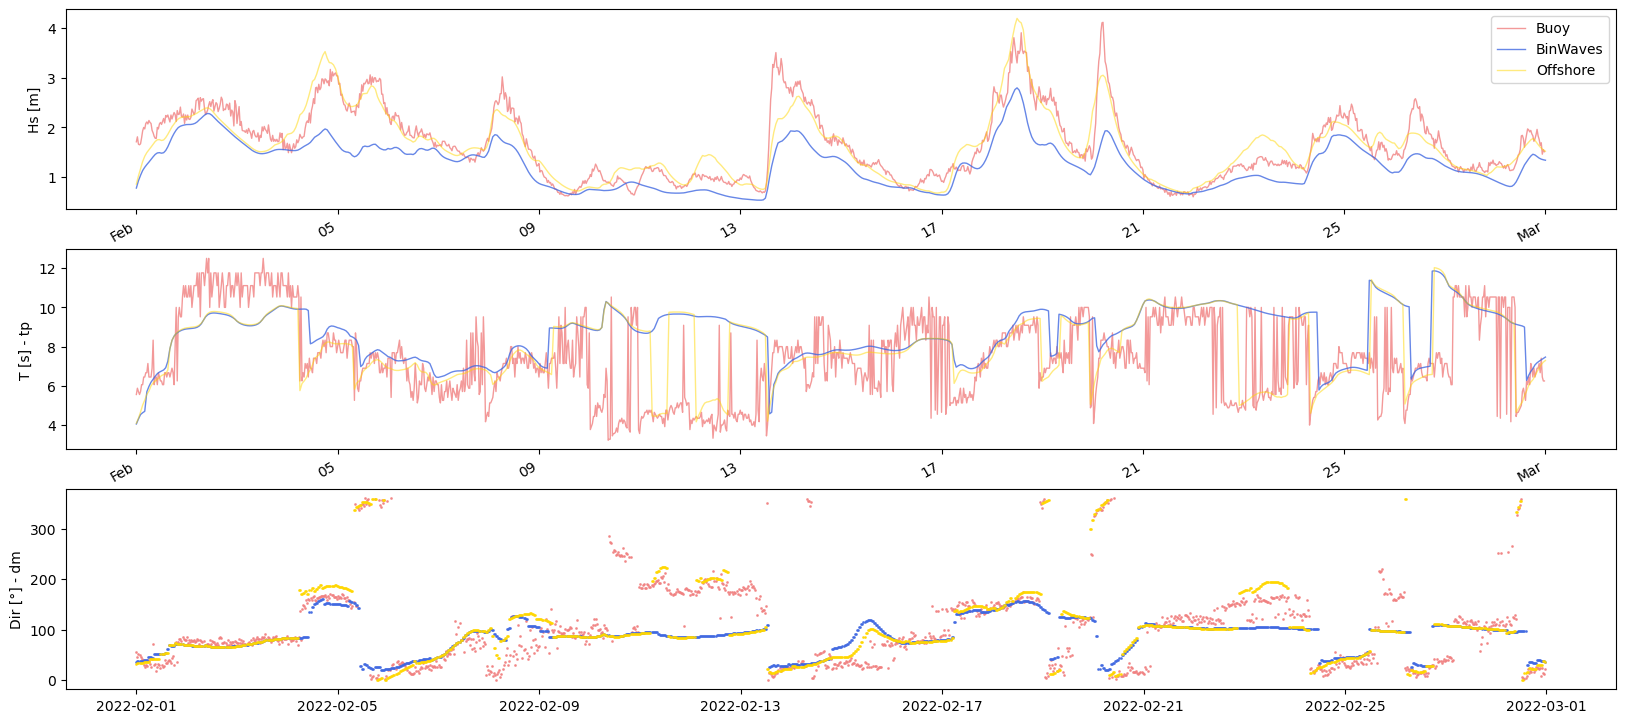

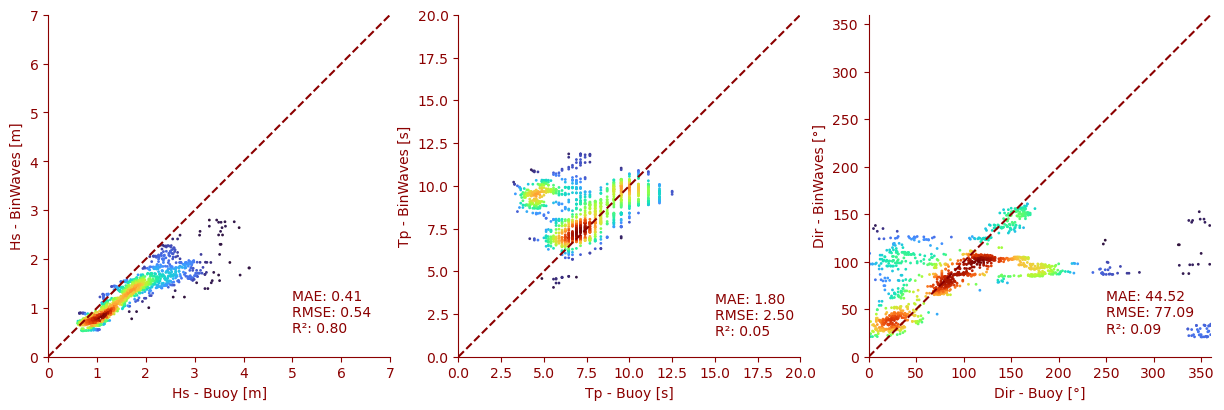

In [6]:
from utils.plotting import plot_wave_series

# Plot reconstructed bulk parameters vs buoy data

# plot_wave_series(
#     buoy_data=buoy_waves,
#     binwaves_data=reconstructed_onshore_spectra.rename({"kps": "efth"})
#     .squeeze()
#     .sel(time=buoy_waves.index, method="nearest")
#     .spec,
#     offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
#     times=buoy_waves.index.values,
# )
# Plot reconstructed bulk parameters vs buoy data
plot_wave_series(
    buoy_data=buoy_waves,
    binwaves_data=reconstructed_onshore_spectra.rename({"kps": "efth"})
    .squeeze()
    .drop_duplicates('time')  # Add this line to remove duplicates
    .sel(time=buoy_waves.index, method="nearest")
    .spec,
    offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
    times=buoy_waves.index.values,
)